## Основной код

In [ ]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt
import glob

In [64]:
class MyStitcher:
    def __init__(self, match_ratio: float = 0.75, min_matches: int = 10):
        self.match_ratio = match_ratio
        self.min_matches = min_matches
        self.detector = cv2.SIFT_create()
        self.matcher = cv2.BFMatcher(cv2.NORM_L2, crossCheck=False)
    
    def detect_and_compute(self, image: np.ndarray) -> tuple[list[cv2.KeyPoint], np.ndarray]:
        """Детектирование и вычисление ключевых точек и дескрипторов"""

        keypoints, descriptors = self.detector.detectAndCompute(image, None)
        
        return keypoints, descriptors
    
    def match_features(self, desc1: np.ndarray, desc2: np.ndarray) -> list[cv2.DMatch]:
        """Сопоставление дескрипторов двух изображений"""  

        # Получаем список матчей
        raw_matches = self.matcher.knnMatch(desc1, desc2, k=2)
        
        # Находим лучшие совпадения
        good_matches = []
        for m, n in raw_matches:
            if m.distance < self.match_ratio * n.distance:
                good_matches.append(m)
        
        return good_matches
    
    def find_homography(self, kp1: list[cv2.KeyPoint], kp2: list[cv2.KeyPoint], matches: list[cv2.DMatch]) -> np.ndarray:
        """Нахождение матрицы гомографии между двумя изображениями"""
        # Извлекаем координаты точек матчей
        src_pts = np.float32([kp1[m.queryIdx].pt for m in matches]).reshape(-1, 1, 2)
        dst_pts = np.float32([kp2[m.trainIdx].pt for m in matches]).reshape(-1, 1, 2)
        
        # Находим матрицу гомографии
        H, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)
        
        # Считаем inliers
        inliers = mask.ravel().tolist()
        inlier_count = sum(inliers)
        inlier_ratio = inlier_count / len(matches)
        
        print(f"Найдено {len(matches)} матчей, из них {inlier_count} inliers ({inlier_ratio:.2%})")
        
        return H

    def warp_images(self, img1: np.ndarray, img2: np.ndarray, H: np.ndarray) -> np.ndarray:
        """Сшивание двух изображений с помощью матрицы гомографии"""
        h1, w1 = img1.shape[:2]
        h2, w2 = img2.shape[:2]
        
        # Получаем углы первого изображения
        corners1 = np.float32([[0, 0], [0, h1], [w1, h1], [w1, 0]]).reshape(-1, 1, 2)
        # Получаем углы второго изображения
        corners2 = np.float32([[0, 0], [0, h2], [w2, h2], [w2, 0]]).reshape(-1, 1, 2)
        
        # Преобразуем углы первого изображения
        warped_corners1 = cv2.perspectiveTransform(corners1, H)
        
        # Объединяем углы обоих изображений
        all_corners = np.concatenate((warped_corners1, corners2), axis=0)
        
        # Находим границы результирующего изображения
        [x_min, y_min] = np.int32(all_corners.min(axis=0).ravel() - 0.5)
        [x_max, y_max] = np.int32(all_corners.max(axis=0).ravel() + 0.5)
        
        # Смещение для компенсации отрицательных координат
        translation = np.array([[1, 0, -x_min], [0, 1, -y_min], [0, 0, 1]])
        
        # Применяем смещение к матрице гомографии
        H_adjusted = translation.dot(H)
        
        # Деформируем первое изображение
        result_width = x_max - x_min
        result_height = y_max - y_min
        
        warped_img1 = cv2.warpPerspective(img1, H_adjusted, (result_width, result_height))
        
        # Копируем деформированное первое изображение
        result = warped_img1.copy()
        
        # Накладываем второе изображение со смещением
        y_offset = -y_min
        x_offset = -x_min
        
        # Определяем область для второго изображения
        y1, y2 = max(0, y_offset), min(result_height, y_offset + h2)
        x1, x2 = max(0, x_offset), min(result_width, x_offset + w2)
        
        y1_src, y2_src = max(0, -y_offset), min(h2, result_height - y_offset)
        x1_src, x2_src = max(0, -x_offset), min(w2, result_width - x_offset)
        
        # Накладываем второе изображение с блендингом
        if y2 > y1 and x2 > x1 and y2_src > y1_src and x2_src > x1_src:
            # Создаем маску для области наложения
            overlay_region = result[y1:y2, x1:x2]
            img2_region = img2[y1_src:y2_src, x1_src:x2_src]
            
            # Создаем маску для пикселей, которые не чёрные в деформированном изображении
            mask1 = (overlay_region.sum(axis=2) > 0)
            mask2 = (img2_region.sum(axis=2) > 0)
            
            # Для области, где есть оба изображения - делаем блендинг
            overlap_mask = mask1 & mask2
            if overlap_mask.any():
                alpha = 0.5  # Для смешивания берём 50% каждого изображения
                overlay_region[overlap_mask] = cv2.addWeighted(
                    overlay_region[overlap_mask], alpha,
                    img2_region[overlap_mask], 1-alpha, 0
                )
            
            # Области, где есть только второе изображение
            only_mask2 = ~mask1 & mask2
            if only_mask2.any():
                overlay_region[only_mask2] = img2_region[only_mask2]
        
        return result
    
    # Опционально (оставил для отладки)
    def visualize_matches(self, img1: np.ndarray, img2: np.ndarray, kp1: list[cv2.KeyPoint], 
                         kp2: list[cv2.KeyPoint], matches: list[cv2.DMatch]) -> None:
        """Визуализация сопоставленных признаков между двумя изображениями"""

        img_matches = cv2.drawMatches(
            img1, kp1, img2, kp2, 
            matches[:50],
            None, 
            flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
        )

        img_matches_rgb = cv2.cvtColor(img_matches, cv2.COLOR_BGR2RGB)

        plt.figure(figsize=(15, 8))
        plt.imshow(img_matches_rgb)
        plt.title("Сопоставление признаков: (показано 50 матчей)")
        plt.axis("off")
        plt.show()
    
    def stitch_pair(self, img1: np.ndarray, img2: np.ndarray, visualize: bool = False) -> np.ndarray:
        """Сшивание пары изображений"""
        print("\n" + "="*50)
        print("Обработка пары изображений...")
        
        # Детектируем признаки
        kp1, desc1 = self.detect_and_compute(img1)
        kp2, desc2 = self.detect_and_compute(img2)
        
        print(f"Найдено ключевых точек: {len(kp1)} и {len(kp2)}")
        
        # Сопоставляем признаки
        matches = self.match_features(desc1, desc2)
        print(f"Найдено хороших матчей: {len(matches)}")
        
        if len(matches) < self.min_matches:
            print(f"Недостаточно матчей для склейки!")
            return None
        
        # Визуализируем матчи
        if visualize and len(matches) > 0:
            self.visualize_matches(img1, img2, kp1, kp2, matches)
        
        # Находим гомографию
        H = self.find_homography(kp1, kp2, matches)
        
        # Сшиваем изображения
        result = self.warp_images(img1, img2, H)
        
        return result
    
    def stitch_auto_order(self, images: list[np.ndarray]) -> np.ndarray:
        """Автоматическое определение порядка склейки на основе количества матчей"""

        print("Определение оптимального порядка склейки...")

        # Вычисляем дескрипторы для всех изображений
        descriptors = []
        
        for img in images:
            kp, desc = self.detect_and_compute(img)
            descriptors.append(desc)
        
        # Создаем матрицу сходства между изображениями
        n = len(images)
        similarity_matrix = np.zeros((n, n))
        
        for i in range(n):
            for j in range(i+1, n):
                matches = self.match_features(descriptors[i], descriptors[j])
                similarity_matrix[i, j] = len(matches)
                similarity_matrix[j, i] = len(matches)
        
        print("Матрица сходства (количество матчей):")
        print(similarity_matrix.astype(int))
        
        # Начинаем с пары с наибольшим количеством матчей
        max_similarity = np.unravel_index(np.argmax(similarity_matrix), similarity_matrix.shape)
        start_idx, next_idx = max_similarity
        
        print(f"\nНачинаем с пары: изображения {start_idx + 1} и {next_idx + 1}")
        
        # Сшиваем первую пару
        result = self.stitch_pair(images[start_idx], images[next_idx])
        used_indices = {start_idx, next_idx}
        
        # Последовательно добавляем остальные изображения
        while len(used_indices) < n:
            best_idx = -1
            best_matches = 0
            
            # Ищем изображение с наибольшим количеством матчей с текущей панорамой
            result_kp, result_desc = self.detect_and_compute(result)
            
            for idx in range(n):
                if idx in used_indices:
                    continue
                
                # Сопоставляем с текущей панорамой
                matches = self.match_features(descriptors[idx], result_desc)
                
                if len(matches) > best_matches:
                    best_matches = len(matches)
                    best_idx = idx
            
            if best_idx == -1 or best_matches < self.min_matches:
                print(f"Не удалось найти подходящее изображение для добавления")
                break
            
            print(f"\nДобавляем изображение {best_idx} с {best_matches} матчами...")
            
            # Сшиваем с найденным изображением
            temp_result = self.stitch_pair(images[best_idx], result, visualize=False)
            
            if temp_result is not None:
                result = temp_result
                used_indices.add(best_idx)
                print(f"Успешно добавлено! Размер панорамы: {result.shape}")
            else:
                print(f"Не удалось добавить изображение {best_idx}, пропускаем...")
                used_indices.add(best_idx)
        
        print(f"\nИспользовано изображений: {len(used_indices)} из {n}")
        
        return result

In [65]:
def load_images_from_folder(folder_path: str) -> tuple[list[np.ndarray], list[str]]:
    """Загрузка изображений из папки"""    
    images = []
    filenames = []
    
    # Поддерживаемые форматы
    extensions = ["*.jpg"]
    
    # Собираем пути всех изображений из папки
    image_files = []
    for ext in extensions:
        image_files.extend(glob.glob(os.path.join(folder_path, ext)))

    image_files.sort()
    
    print(f"Найдено {len(image_files)} изображений:")
    
    for i, img_path in enumerate(image_files):
        img = cv2.imread(img_path)
        if img is not None:
            images.append(img)
            filenames.append(os.path.basename(img_path))
            print(f"{i + 1}. {os.path.basename(img_path)} - {img.shape}")
            
            # Показываем найденные изображения
            plt.figure(figsize=(2, 1.5))
            plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
            plt.title(f"{i+1}")
            plt.axis("off")
            plt.show()
    
    return images, filenames

In [66]:
def crop_black_borders(image: np.ndarray, threshold: int = 10) -> np.ndarray:
    """Обрезка чёрных полей"""
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    
    # Находим ненулевые пиксели
    coords = np.column_stack(np.where(gray > threshold))
    
    if len(coords) == 0:
        return image
    
    # Находим bounding box
    y_min, x_min = coords.min(axis=0)
    y_max, x_max = coords.max(axis=0)
    
    # Обрезаем
    cropped = image[y_min:y_max+1, x_min:x_max+1]
    
    return cropped

In [67]:
def main_panorama_pipeline(folder_path: str, save_path: str) -> None:
    """Полный пайплайн создания панорамы"""
    
    # Шаг 1: Загрузка изображений
    print("\nШАГ 1: Загрузка изображений...")
    images, filenames = load_images_from_folder(folder_path)
    
    # Шаг 2: Инициализация ститчера
    print("\nШАГ 2: Инициализация ститчера...")
    stitcher = MyStitcher(
        match_ratio=0.75,
        min_matches=10
    )
    
    # Шаг 3: Склейка изображений
    print("\nШАГ 3: Склейка изображений...")
    panorama = stitcher.stitch_auto_order(images)
    
    # Шаг 4: Обрезка чёрных полей
    print("\nШАГ 4: Обрезка чёрных полей...")
    cropped_panorama = crop_black_borders(panorama)
    
    # Шаг 5: Отображение результатов
    print("\nШАГ 5: Отображение результатов...")
    plt.imshow(cv2.cvtColor(cropped_panorama, cv2.COLOR_BGR2RGB))
    plt.title("Полученная панорама")
    plt.axis("off")
    plt.show()
    
    # Шаг 6: Сохранение результатов
    # P.S. при сохранении в формат .jpg появляются чёрные полосы при приближении, вероятно, из-за сжатия
    print("\nШАГ 6: Сохранение результатов...")
    os.makedirs(f"{save_path}", exist_ok=True)
    cv2.imwrite(f"{save_path}/panorama.jpg", cropped_panorama)

## -----------------------------------------------------------------------------------------

## map1


ШАГ 1: Загрузка изображений...
Найдено 10 изображений:
1. img01.jpg - (1000, 1000, 3)


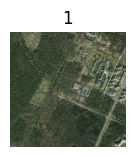

2. img02.jpg - (1000, 1000, 3)


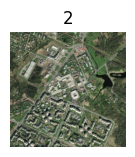

3. img03.jpg - (1000, 1000, 3)


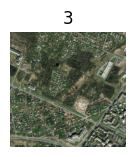

4. img04.jpg - (1000, 1000, 3)


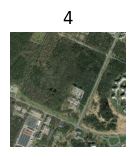

5. img05.jpg - (1000, 1000, 3)


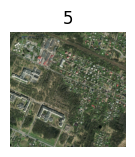

6. img06.jpg - (1000, 1000, 3)


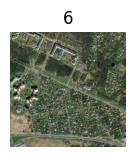

7. img07.jpg - (1000, 1000, 3)


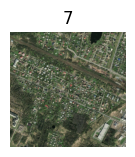

8. img08.jpg - (1000, 1000, 3)


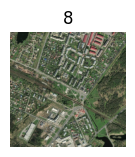

9. img09.jpg - (1000, 1000, 3)


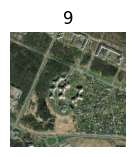

10. img10.jpg - (1000, 1000, 3)


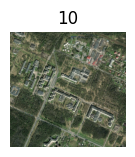


ШАГ 2: Инициализация ститчера...

ШАГ 3: Склейка изображений...
Определение оптимального порядка склейки...
Матрица сходства (количество матчей):
[[   0   29   20 7785   35  413   24   26 3148 5306]
 [  29    0 4765   70   53   66 2189 6612   60   54]
 [  20 4765    0   58 4818 7628 6269 2007 1763 1452]
 [7785   70   58    0   41  726   30   25 6233 2310]
 [  35   53 4818   41    0 5610 9056   36 2805 8942]
 [ 413   66 7628  726 5610    0 3933   38 7693 3985]
 [  24 2189 6269   30 9056 3933    0 4996  543 2422]
 [  26 6612 2007   25   36   38 4996    0   80   66]
 [3148   60 1763 6233 2805 7693  543   80    0 5410]
 [5306   54 1452 2310 8942 3985 2422   66 5410    0]]

Начинаем с пары: изображения 5 и 7

Обработка пары изображений...
Найдено ключевых точек: 16679 и 17102
Найдено хороших матчей: 9056
Найдено 9056 матчей, из них 9025 inliers (99.66%)

Добавляем изображение 9 с 8721 матчами...

Обработка пары изображений...
Найдено ключевых точек: 15896 и 23354
Найдено хороших матчей: 87

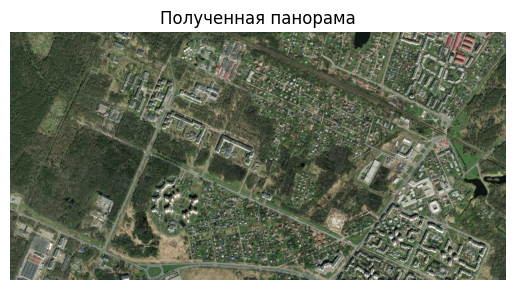


ШАГ 6: Сохранение результатов...


In [68]:
FOLDER_PATH = "data/map1"
SAVE_PATH = "results/map1"
main_panorama_pipeline(FOLDER_PATH, SAVE_PATH)

## -----------------------------------------------------------------------------------------

## map2


ШАГ 1: Загрузка изображений...
Найдено 8 изображений:
1. img01.jpg - (1000, 1000, 3)


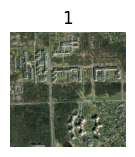

2. img02.jpg - (1000, 1000, 3)


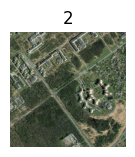

3. img03.jpg - (1000, 1000, 3)


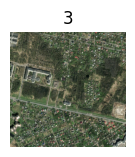

4. img04.jpg - (1000, 1000, 3)


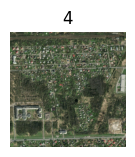

5. img05.jpg - (1000, 1000, 3)


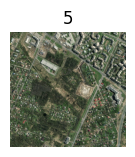

6. img06.jpg - (1000, 1000, 3)


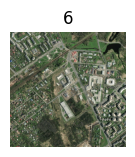

7. img07.jpg - (1000, 1000, 3)


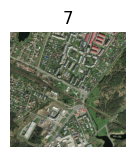

8. img08.jpg - (1000, 1000, 3)


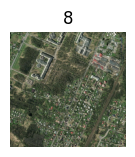


ШАГ 2: Инициализация ститчера...

ШАГ 3: Склейка изображений...
Определение оптимального порядка склейки...
Матрица сходства (количество матчей):
[[    0  9869  5039  2789   332    52    47  4734]
 [ 9869     0  3671  1756   184    70    54  3419]
 [ 5039  3671     0  9973  7961  2919   768  8441]
 [ 2789  1756  9973     0  7760  4818  2509 10024]
 [  332   184  7961  7760     0  8046  3294  4314]
 [   52    70  2919  4818  8046     0  9328  2395]
 [   47    54   768  2509  3294  9328     0   255]
 [ 4734  3419  8441 10024  4314  2395   255     0]]

Начинаем с пары: изображения 4 и 8

Обработка пары изображений...
Найдено ключевых точек: 19219 и 23203
Найдено хороших матчей: 10024
Найдено 10024 матчей, из них 9997 inliers (99.73%)

Добавляем изображение 2 с 10460 матчами...

Обработка пары изображений...
Найдено ключевых точек: 19606 и 27368
Найдено хороших матчей: 10460
Найдено 10460 матчей, из них 10436 inliers (99.77%)
Успешно добавлено! Размер панорамы: (1440, 1490, 3)

Добавляем 

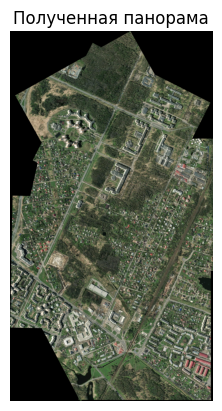


ШАГ 6: Сохранение результатов...


In [69]:
FOLDER_PATH = "data/map2"
SAVE_PATH = "results/map2"
main_panorama_pipeline(FOLDER_PATH, SAVE_PATH)

## -----------------------------------------------------------------------------------------

## map3


ШАГ 1: Загрузка изображений...
Найдено 8 изображений:
1. img01.jpg - (600, 600, 3)


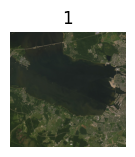

2. img02.jpg - (600, 600, 3)


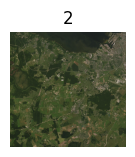

3. img03.jpg - (600, 600, 3)


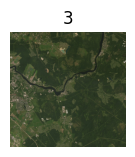

4. img04.jpg - (600, 600, 3)


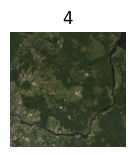

5. img05.jpg - (600, 600, 3)


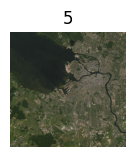

6. img06.jpg - (600, 600, 3)


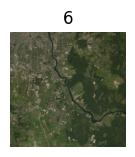

7. img07.jpg - (600, 600, 3)


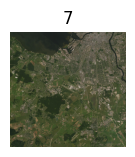

8. img08.jpg - (600, 600, 3)


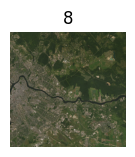


ШАГ 2: Инициализация ститчера...

ШАГ 3: Склейка изображений...
Определение оптимального порядка склейки...
Матрица сходства (количество матчей):
[[   0  495    1    7  497    3  341   50]
 [ 495    0   19   10  641   77 1548  175]
 [   1   19    0  643   21  842   54  542]
 [   7   10  643    0  226 1014  195  881]
 [ 497  641   21  226    0  620 1237  836]
 [   3   77  842 1014  620    0 1291 1566]
 [ 341 1548   54  195 1237 1291    0 1024]
 [  50  175  542  881  836 1566 1024    0]]

Начинаем с пары: изображения 6 и 8

Обработка пары изображений...
Найдено ключевых точек: 3608 и 2907
Найдено хороших матчей: 1566
Найдено 1566 матчей, из них 1555 inliers (99.30%)

Добавляем изображение 6 с 1325 матчами...

Обработка пары изображений...
Найдено ключевых точек: 4422 и 4292
Найдено хороших матчей: 1325
Найдено 1325 матчей, из них 1317 inliers (99.40%)
Успешно добавлено! Размер панорамы: (1083, 1111, 3)

Добавляем изображение 1 с 1410 матчами...

Обработка пары изображений...
Найдено клю

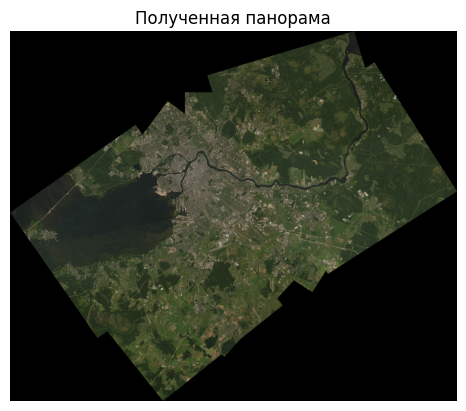


ШАГ 6: Сохранение результатов...


In [70]:
FOLDER_PATH = "data/map3"
SAVE_PATH = "results/map3"
main_panorama_pipeline(FOLDER_PATH, SAVE_PATH)